In [16]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv('../Data/datamain.csv')
print(df.head())
print(df.columns.tolist())

   skill_match_score  experience_match_score  semantic_similarity_score  \
0               0.17                    0.62                     0.5825   
1               0.00                    1.00                     0.6030   
2               0.00                    1.00                     0.4904   
3               0.00                    1.00                     0.4277   
4               0.00                    1.00                     0.5142   

   domain_match  final_score    match_label  num_match_label  
0             1         0.55  partial match              0.5  
1             0         0.27       no match              0.0  
2             0         0.46  partial match              0.5  
3             0         0.09       no match              0.0  
4             0         0.66  partial match              0.5  
['skill_match_score', 'experience_match_score', 'semantic_similarity_score', 'domain_match', 'final_score', 'match_label', 'num_match_label']


LOGISTIC REGRESSION ANALYSIS FOR MATCH LABEL

In [3]:
# Select features and target
# -----------------------------
X = df[['skill_match_score', 'experience_match_score','semantic_similarity_score','domain_match','final_score']]   
y = df['match_label']                               

# -----------------------------
# Split the dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Scale the features
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Create and train the model
# -----------------------------
model = LogisticRegression()

model.fit(X_train, y_train)

# -----------------------------
# Model parameters
# -----------------------------
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# # -----------------------------
# # Predict on new data
# # -----------------------------
# new_data = [[, value2, value3]]   # Replace with actual values

# # Scale using the same scaler
# new_data = scaler.transform(new_data)

# prediction = model.predict(new_data)
# probability = model.predict_proba(new_data)

# print("\nPrediction:", prediction[0])
# print("Probabilities:", probability)

Weights: [[ 0.56652941 -0.04955986  0.33710705  0.42620549  5.33981017]
 [-0.39034043  0.11815347 -0.48211287 -0.47518008 -5.35941042]
 [-0.17618898 -0.06859361  0.14500582  0.04897459  0.01960024]]
Bias: [-1.71810674 -0.62845193  2.34655867]
Accuracy: 0.96

Confusion Matrix:
[[27  0  0]
 [ 0 37  1]
 [ 2  1 32]]

Classification Report:
               precision    recall  f1-score   support

        match       0.93      1.00      0.96        27
     no match       0.97      0.97      0.97        38
partial match       0.97      0.91      0.94        35

     accuracy                           0.96       100
    macro avg       0.96      0.96      0.96       100
 weighted avg       0.96      0.96      0.96       100



DIMENSIONALITY ANALYSIS ON 2-D TO VERIFY LACK OF PERFORMANCE OF LOG-REG (for PARTIAL MATCH OUTPUT)

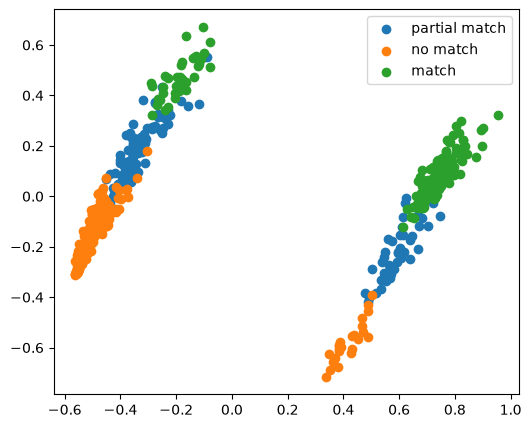

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(6,5))
for label in y.unique():
    idx = (y == label)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label)
plt.legend()
plt.show()

RANDOM FOREST CLASSIFIER [NON LINEAR CLASSIFICATION]

In [5]:
from sklearn.model_selection import cross_val_score

# Features and target
X = df.drop(["match_label",'num_match_label'], axis=1)
y = df["match_label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5)
print(scores)
print("Mean Accuracy:", scores.mean())
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

KeyboardInterrupt: 

In [ ]:
scores = cross_val_score(rf_model, X, y, cv=5)
print(scores)
print("Mean Accuracy:", scores.mean())
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)
print(importance)

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
                     Feature  Importance
4                final_score    0.744832
2  semantic_similarity_score    0.111727
0          skill_match_score    0.102176
3               domain_match    0.030756
1     experience_match_score    0.010509


COMPOSITE SCORING AND SCALING with CHECKING SCORE DEPENDENCY ON FEATURES AND TARGET VAR

In [7]:

# Features to scale
features = [
    "skill_match_score",
    "experience_match_score",
    "semantic_similarity_score",
    "domain_match",
    "final_score"
]

# Scale features to the range [0, 1]
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

# Compute composite score
df_scaled["composite_score"] = (
    0.102176 * df_scaled["skill_match_score"] +
    0.010509 * df_scaled["experience_match_score"] +
    0.111727 * df_scaled["semantic_similarity_score"] +
    0.030756 * df_scaled["domain_match"] +
    0.744832 * df_scaled["final_score"]
)

# Display
print(df_scaled[features + ["composite_score"]].head())

   skill_match_score  experience_match_score  semantic_similarity_score  \
0               0.17                0.512821                   0.538443   
1               0.00                1.000000                   0.589122   
2               0.00                1.000000                   0.310754   
3               0.00                1.000000                   0.155748   
4               0.00                1.000000                   0.369592   

   domain_match  final_score  composite_score  
0           1.0     0.537634         0.514121  
1           0.0     0.236559         0.252527  
2           0.0     0.440860         0.373595  
3           0.0     0.043011         0.059946  
4           0.0     0.655914         0.540348  


In [ ]:
print(df_scaled.groupby("match_label")["composite_score"].describe())    

corr = df_scaled["composite_score"].corr(df["num_match_label"])
print(f"Correlation: {corr:.4f}")



               count      mean       std       min       25%       50%  \
match_label                                                              
match          158.0  0.805383  0.062935  0.662348  0.756541  0.798303   
no match       190.0  0.200249  0.086696  0.044522  0.124968  0.201295   
partial match  152.0  0.521974  0.093173  0.304889  0.446394  0.512313   

                    75%       max  
match_label                        
match          0.851192  0.970090  
no match       0.273105  0.375916  
partial match  0.600681  0.726979  
Correlation: 0.9506


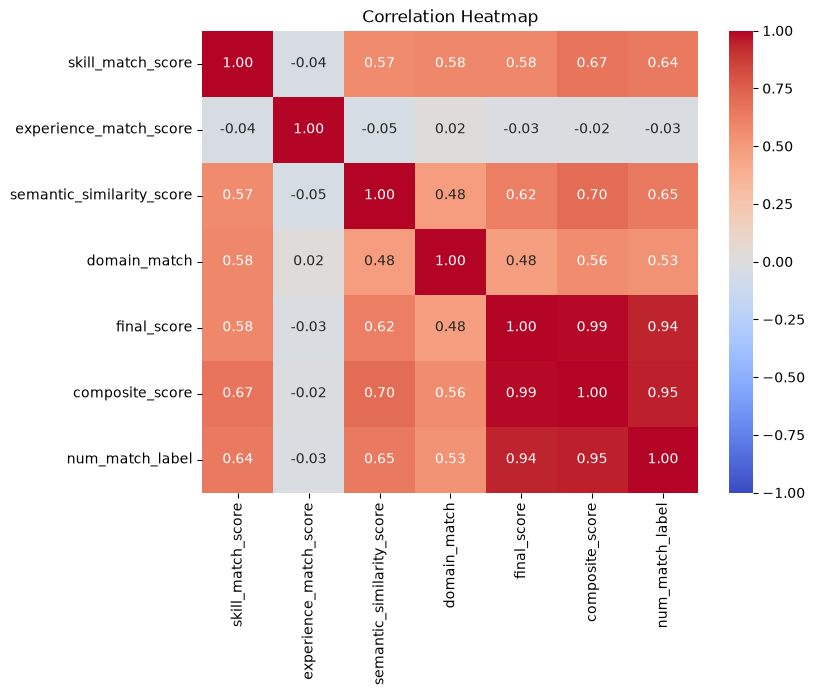

In [18]:
corr_matrix = df_scaled[features +['composite_score']+ ["num_match_label"]].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap")
plt.show()